# Sentinel-1 Feature Engineering for Urban Heat Island Prediction — Rome

This notebook collects Sentinel-1 SAR data over Rome and engineers a rich set of features
for predicting / explaining Land Surface Temperature (LST).

## Why these features?

Landsat gives you optical and thermal information. Sentinel-1 adds three things Landsat **cannot** see:

| SAR feature group | Physical meaning | LST relevance |
|---|---|---|
| VV backscatter | Surface roughness, impervious texture, double-bounce from buildings | Urban fabric density |
| VH backscatter | Vegetation volume, canopy moisture, depolarisation | Latent heat / evapotranspiration proxy |
| VV−VH contrast | Built-up vs vegetated discrimination | Land cover type |
| VH/VV ratio | Cross-pol fraction — pure canopy depth signal | Canopy cooling potential |
| Temporal std (VV, VH) | Seasonal change — construction activity, crop cycles, soil moisture | Dynamic land-cover signal |
| Radar Forest Degradation Index (RFDI) | Forest / dense vegetation health | Cooling capacity |
| SAR urban index | Intensity of double-bounce → building density proxy | Heat trapping |
| Local texture (GLCM contrast) | Spatial heterogeneity of urban fabric | Canyon effect |

## Workflow

```
1. Auth & AOI
2. Load S1 collection (summer + full-year)
3. Speckle filtering (Lee filter)
4. Build summer median composite
5. Engineer all features
6. Visualise
7. Sample to pixel table at 30 m (matches Landsat LST grid)
8. Export CSV
```

**Setup (run once):**
```bash
pip install earthengine-api geemap
```
Then create a free Earth Engine account at https://earthengine.google.com and note your Cloud project id.

## 1. Authenticate and initialise

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np

# First run: uncomment the next line, authenticate, then comment it back.
# ee.Authenticate()

ee.Initialize(project='first-test-project-492808')   # <-- replace with your GCP project id
print('Earth Engine initialised.')

Earth Engine initialised.


## 2. Define AOI and time windows

We use **two** time windows:
- **Summer composite** (Jun–Sep): matches the Landsat LST acquisition window; captures peak UHI.
- **Full-year collection**: used to compute temporal standard deviation (seasonal variability signal).

In [4]:
# Bounding box around Rome (lon_min, lat_min, lon_max, lat_max)
aoi = ee.Geometry.Rectangle([12.35, 41.78, 12.65, 42.00])

# Summer window — peak UHI season, matches Landsat target
SUMMER_START = '2025-06-01'
SUMMER_END   = '2025-09-01'

# Full year — for temporal variability features
YEAR_START   = '2025-01-01'
YEAR_END     = '2025-12-31'

# Output resolution (30 m = Landsat LST native resolution)
SCALE = 30

print(f'AOI: Rome bounding box')
print(f'Summer window : {SUMMER_START} → {SUMMER_END}')
print(f'Full-year window: {YEAR_START} → {YEAR_END}')
print(f'Output scale : {SCALE} m')

AOI: Rome bounding box
Summer window : 2025-06-01 → 2025-09-01
Full-year window: 2025-01-01 → 2025-12-31
Output scale : 30 m


## 3. Load and filter the Sentinel-1 collection

We fix orbit direction to ASCENDING so all images have consistent geometry.
Both VV and VH polarisations are required.

In [5]:
def load_s1(start, end):
    """Load Sentinel-1 GRD IW collection with VV+VH over the AOI."""
    return (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(start, end)
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
        .select(['VV', 'VH'])
    )

s1_summer = load_s1(SUMMER_START, SUMMER_END)
s1_year   = load_s1(YEAR_START,   YEAR_END)

print('Summer images:', s1_summer.size().getInfo())
print('Full-year images:', s1_year.size().getInfo())

Summer images: 22
Full-year images: 71


## 4. Speckle filtering — refined Lee filter

SAR images are degraded by speckle noise (pixel-level random noise from coherent interference).
The **refined Lee filter** is a standard spatial smoother that suppresses speckle while preserving
edges (important for distinguishing urban from vegetated areas).

We apply it to each image in the collection before compositing.

In [6]:
def refined_lee(image):
    """
    Apply a refined Lee speckle filter to a single S1 image.
    Works band-by-band in linear scale, then converts back to dB.
    Kernel size: 7×7 (good balance of smoothing vs edge preservation).
    """
    # Convert from dB to linear power for the filter
    img_linear = ee.Image(10).pow(image.divide(10))

    # Local statistics in a 7×7 kernel
    kernel = ee.Kernel.square(radius=3.5, units='pixels')   # 7×7
    mean   = img_linear.reduceNeighborhood(ee.Reducer.mean(),   kernel)
    var    = img_linear.reduceNeighborhood(ee.Reducer.variance(), kernel)

    # Estimated noise variance (ENL ≈ 4.9 for GRD IW)
    enl = 4.9
    noise_var = mean.pow(2).divide(enl)

    # Lee filter weight: w = signal_var / (signal_var + noise_var)
    signal_var = var.subtract(noise_var).max(ee.Image(0))
    weight     = signal_var.divide(var.max(ee.Image(1e-10)))

    # Filtered value: mean + w * (pixel - mean)
    filtered = mean.add(weight.multiply(img_linear.subtract(mean)))

    # Back to dB
    filtered_db = filtered.log10().multiply(10)

    return filtered_db.rename(image.bandNames()).copyProperties(image, image.propertyNames())


# Apply to both collections
s1_summer_filtered = s1_summer.map(refined_lee)
s1_year_filtered   = s1_year.map(refined_lee)

print('Speckle filter applied to both collections.')

Speckle filter applied to both collections.


## 5. Build the summer composite

We use the **median** reducer across all summer passes to:
- Further suppress residual speckle
- Remove transient anomalies (wet ground after rain, construction noise)
- Get a stable seasonal mean signal

In [7]:
composite = s1_summer_filtered.median().clip(aoi)

print('Summer composite bands:', composite.bandNames().getInfo())

Summer composite bands: ['VV', 'VH']


## 6. Feature engineering

We derive 9 features from Sentinel-1. Each has a clear physical interpretation
and a direct link to either heat absorption, thermal storage, or cooling mechanisms.

### Feature catalogue

| Feature | Formula | Physical meaning |
|---|---|---|
| `VV` | raw | Surface roughness / impervious texture / building double-bounce |
| `VH` | raw | Vegetation volume / canopy moisture (cross-pol depolarisation) |
| `VV_VH_diff` | VV − VH | Urban vs vegetation discriminator (high = urban) |
| `VH_VV_ratio` | VH / VV | Cross-pol fraction — pure canopy depth signal (low = urban) |
| `RFDI` | (VV−VH)/(VV+VH) | Radar Forest Degradation Index: 1=bare/urban, −1=dense forest |
| `SAR_urban` | VV² / VH | Amplifies double-bounce; high over dense built fabric |
| `VV_std` | std(VV) over year | Temporal variability: construction, seasonal soil moisture |
| `VH_std` | std(VH) over year | Vegetation seasonality: high = cropland/deciduous, low = evergreen |
| `texture_contrast` | GLCM contrast of VV | Local texture heterogeneity: high = complex urban canyon |


In [8]:
# ── 6a. Raw bands ──────────────────────────────────────────────────────────────
VV = composite.select('VV')
VH = composite.select('VH')

# ── 6b. VV − VH difference (dB units → additive ratio) ────────────────────────
# High value (>10 dB) → urban/impervious (strong co-pol, weak cross-pol)
# Low value (<5 dB)   → vegetation (VH is relatively strong)
VV_VH_diff = VV.subtract(VH).rename('VV_VH_diff')

# ── 6c. VH/VV ratio (linear) ──────────────────────────────────────────────────
# Convert to linear first so the ratio is physically meaningful
VV_lin = ee.Image(10).pow(VV.divide(10))
VH_lin = ee.Image(10).pow(VH.divide(10))
VH_VV_ratio = VH_lin.divide(VV_lin).rename('VH_VV_ratio')
# High ratio → strong depolarisation → dense canopy
# Low ratio  → weak depolarisation   → smooth/urban surface

# ── 6d. Radar Forest Degradation Index (RFDI) ──────────────────────────────────
# RFDI = (VV_lin − VH_lin) / (VV_lin + VH_lin)
# Ranges from −1 (intact forest) to +1 (bare/urban)
# Very useful because it's normalised — robust to absolute backscatter level
RFDI = (VV_lin.subtract(VH_lin)
        .divide(VV_lin.add(VH_lin))
        .rename('RFDI'))

# ── 6e. SAR Urban Index ────────────────────────────────────────────────────────
# SAR_urban = VV_lin² / VH_lin
# Amplifies double-bounce (dominant in urban), suppresses volume scattering
# Log-transform it to keep it in a sensible range for the model
SAR_urban = (VV_lin.pow(2)
             .divide(VH_lin.max(ee.Image(1e-6)))
             .log10().multiply(10)   # back to dB-like scale
             .rename('SAR_urban'))

print('Static features computed: VV, VH, VV_VH_diff, VH_VV_ratio, RFDI, SAR_urban')

Static features computed: VV, VH, VV_VH_diff, VH_VV_ratio, RFDI, SAR_urban


In [9]:
# ── 6f. Temporal variability features (full-year stdDev) ───────────────────────
#
# WHY THIS MATTERS:
#   - High VV_std → the surface is changing (construction, ploughing, flooding)
#     → less stable thermal inertia
#   - High VH_std → vegetation is seasonal (cropland, deciduous trees)
#     → LST varies with phenology; parks vs crops behave differently even at same NDVI
#   - Low VH_std  → evergreen vegetation or stable bare/urban surface
#
# These features are UNIQUE to SAR — optical indices are often cloud-contaminated
# in winter, making stable annual stats hard to compute from Landsat.

year_stddev = s1_year_filtered.reduce(ee.Reducer.stdDev()).clip(aoi)

VV_std = year_stddev.select('VV_stdDev').rename('VV_std')
VH_std = year_stddev.select('VH_stdDev').rename('VH_std')

print('Temporal variability features computed: VV_std, VH_std')

Temporal variability features computed: VV_std, VH_std


In [10]:
# ── 6g. Texture feature: GLCM Contrast on VV ──────────────────────────────────
#
# WHY THIS MATTERS:
#   Urban areas with dense, mixed building heights produce high local texture
#   (adjacent pixels vary strongly in backscatter).
#   This captures the CANYON EFFECT that BH and BD don't fully encode:
#   two areas with the same mean building height can have very different
#   spatial heterogeneity, which affects airflow and shadow patterns.
#
# GLCM = Grey-Level Co-occurrence Matrix
# 'contrast' = sum of (i-j)^2 * p(i,j)  — measures local intensity variation
# We compute it on a 5×5 neighbourhood at 30 m resolution.
#
# Note: GEE's glcmTexture() expects integer inputs.
# We quantise VV from dB range [−25, 0] into 64 grey levels.

VV_quantised = (VV
                .add(25)               # shift to [0, 25]
                .divide(25)            # normalise to [0, 1]
                .multiply(63)          # scale to [0, 63]
                .round()               # integer
                .toInt())

glcm = VV_quantised.glcmTexture(size=5)   # 5-pixel radius = 11×11 window at 30 m

texture_contrast = glcm.select('VV_contrast').rename('texture_contrast')

print('Texture feature computed: texture_contrast (GLCM contrast of VV)')

Texture feature computed: texture_contrast (GLCM contrast of VV)


In [11]:
# ── 6h. Assemble the full feature image ───────────────────────────────────────

s1_features = (
    composite                       # VV, VH
    .addBands(VV_VH_diff)
    .addBands(VH_VV_ratio)
    .addBands(RFDI)
    .addBands(SAR_urban)
    .addBands(VV_std)
    .addBands(VH_std)
    .addBands(texture_contrast)
)

band_names = s1_features.bandNames().getInfo()
print(f'Total S1 feature bands ({len(band_names)}):')
for b in band_names:
    print(f'  {b}')

Total S1 feature bands (9):
  VV
  VH
  VV_VH_diff
  VH_VV_ratio
  RFDI
  SAR_urban
  VV_std
  VH_std
  texture_contrast


## 7. Visualise the features

The false-colour composite uses:
- **Red** = VV (built-up areas glow)
- **Green** = VH (vegetation glows)
- **Blue** = RFDI (forest/dense green = dark, urban = bright)

Toggle individual layers to inspect each feature.

In [24]:
Map = geemap.Map()
Map.centerObject(aoi, 11)

# Raw backscatter
Map.addLayer(s1_features.select('VV'),
             {'min': -25, 'max': 0, 'palette': ['#000033', '#003399', '#ffffff']},
             'VV (dB)')

Map.addLayer(s1_features.select('VH'),
             {'min': -30, 'max': -5, 'palette': ['#000033', '#006633', '#ccffcc']},
             'VH (dB)')

# Urban/vegetation discriminator
Map.addLayer(s1_features.select('VV_VH_diff'),
             {'min': 0, 'max': 15, 'palette': ['#003399', '#ffffff', '#cc3300']},
             'VV−VH (urban=bright)')

# RFDI: 1=urban/bare, -1=forest
Map.addLayer(s1_features.select('RFDI'),
             {'min': -0.5, 'max': 0.5, 'palette': ['#006600', '#ffffff', '#cc3300']},
             'RFDI (red=urban, green=forest)')

# Temporal variability of VH — vegetation seasonality
Map.addLayer(s1_features.select('VH_std'),
             {'min': 0, 'max': 3, 'palette': ['#ffffff', '#ffaa00', '#cc0000']},
             'VH temporal std (high=seasonal veg/cropland)')

# Texture
Map.addLayer(s1_features.select('texture_contrast'),
             {'min': 0, 'max': 200, 'palette': ['#ffffff', '#666666', '#000000']},
             'GLCM contrast (high=complex urban)')

# False-colour composite
Map.addLayer(
    s1_features,
    {'bands': ['VV', 'VH', 'RFDI'],
     'min': [-25, -30, -0.5],
     'max': [0, -5, 0.5]},
    'S1 false colour (R=VV, G=VH, B=RFDI)'
)

Map

Map(center=[41.89003445667141, 12.500000000001013], controls=(WidgetControl(options=['position', 'transparent_…

## 8. Sample to pixel table at 30 m

We reproject everything to EPSG:32633 (UTM zone 33N, metres) at 30 m to match Landsat.
Each row in the output CSV = one 30×30 m pixel with all 9 S1 features + coordinates.

Later you will join this table with Landsat LST (target) and optical features (NDVI etc.)
on the pixel coordinates to build the final modelling dataset.

In [ ]:
# # Reproject to UTM 33N at 30 m to match Landsat grid exactly
# s1_grid = s1_features.reproject(crs='EPSG:32633', scale=SCALE)

# # Sample — use a systematic sample (every pixel) for a small AOI,
# # or a random sample for large areas (start with 10 000 for testing).
# samples = s1_grid.sample(
#     region=aoi,
#     scale=SCALE,
#     numPixels=1_000,       # increase to ~200 000 for final analysis
#     seed=42,
#     geometries=True         # keep lat/lon for spatial joins
# )

# print(f'Sampled pixels: {samples.size().getInfo()}')

In [19]:
# # Pull to local memory and convert to DataFrame
# features_list = samples.getInfo()['features']

# rows = []
# for feat in features_list:
#     row = dict(feat['properties'])
#     coords = feat['geometry']['coordinates']
#     row['lon'] = coords[0]
#     row['lat'] = coords[1]
#     rows.append(row)

# df = pd.DataFrame(rows)

# # Reorder columns for clarity
# col_order = ['lon', 'lat', 'VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio',
#              'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast']
# df = df[col_order]

# print(f'DataFrame shape: {df.shape}')
# print('\nColumn ranges:')
# print(df.describe().round(3))

In [ ]:
# Step 1: export the full raster to Google Drive
task = ee.batch.Export.image.toDrive(
    image=s1_features,
    description='rome_s1_features_30m_full',
    folder='UHI_Rome',
    scale=SCALE,
    crs='EPSG:32633',
    region=aoi,
    maxPixels=1e9,
    fileFormat='GeoTIFF'
)
task.start()
print('Export started — check Tasks tab at code.earthengine.google.com')

Export started — check Tasks tab at code.earthengine.google.com


In [21]:
import rasterio
import numpy as np
import pandas as pd

band_names = ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio',
              'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast']

with rasterio.open('rome_s1_features_30m_full.tif') as src:
    data = src.read()   # shape: (9, rows, cols)
    nodata = src.nodata

    rows_idx, cols_idx = np.meshgrid(
        np.arange(src.height), np.arange(src.width), indexing='ij'
    )
    xs, ys = rasterio.transform.xy(
        src.transform, rows_idx.ravel(), cols_idx.ravel()
    )

df = pd.DataFrame({
    name: data[i].ravel() for i, name in enumerate(band_names)
})
df['x_utm'] = xs
df['y_utm'] = ys

# Drop nodata
if nodata is not None:
    df = df[df['VV'] != nodata]
df = df.dropna().reset_index(drop=True)

print(f'Total pixels: {len(df):,}')
df.head()

Total pixels: 677,735


,VV,VH,VV_VH_diff,VH_VV_ratio,RFDI,SAR_urban,VV_std,VH_std,texture_contrast,x_utm,y_utm
0,-10.388566,-16.534420,6.145855,0.242893,0.609149,-4.242711,0.527717,0.708021,0.805000,280515.0,4653165.0
1,-10.671421,-16.463101,5.791680,0.263531,0.582866,-4.879741,0.641854,0.906207,0.961310,280545.0,4653165.0
2,-10.706261,-16.585046,5.878785,0.258298,0.589448,-4.827475,0.468242,0.716338,0.978869,280575.0,4653165.0
3,-10.472099,-16.476226,6.004127,0.250950,0.598785,-4.467972,0.590233,0.698900,0.965278,280605.0,4653165.0
4,-10.537540,-16.623564,6.086025,0.246262,0.604799,-4.451515,0.597549,0.548910,0.969630,280635.0,4653165.0


In [22]:
import pyproj

transformer = pyproj.Transformer.from_crs(
    'EPSG:32633',   # UTM 33N (source)
    'EPSG:4326',    # WGS84 lon/lat (target)
    always_xy=True
)

df['lon'], df['lat'] = transformer.transform(
    df['x_utm'].values,
    df['y_utm'].values
)

print(df[['x_utm', 'y_utm', 'lon', 'lat']].head(3))

      x_utm      y_utm        lon        lat
0  280515.0  4653165.0  12.349883  41.999919
1  280545.0  4653165.0  12.350245  41.999928
2  280575.0  4653165.0  12.350606  41.999936


## 9. Quick sanity check — feature distributions

Check that the distributions make physical sense:
- `VV` should be bimodal: a dark cluster (water/smooth, around −18 to −22) and a bright cluster (urban, around −6 to −3)
- `RFDI` should have a peak near +0.3–0.5 for urban pixels and near −0.2 for parks
- `VH_std` should be higher in the agricultural Campagna Romana (east/south) than in the city centre

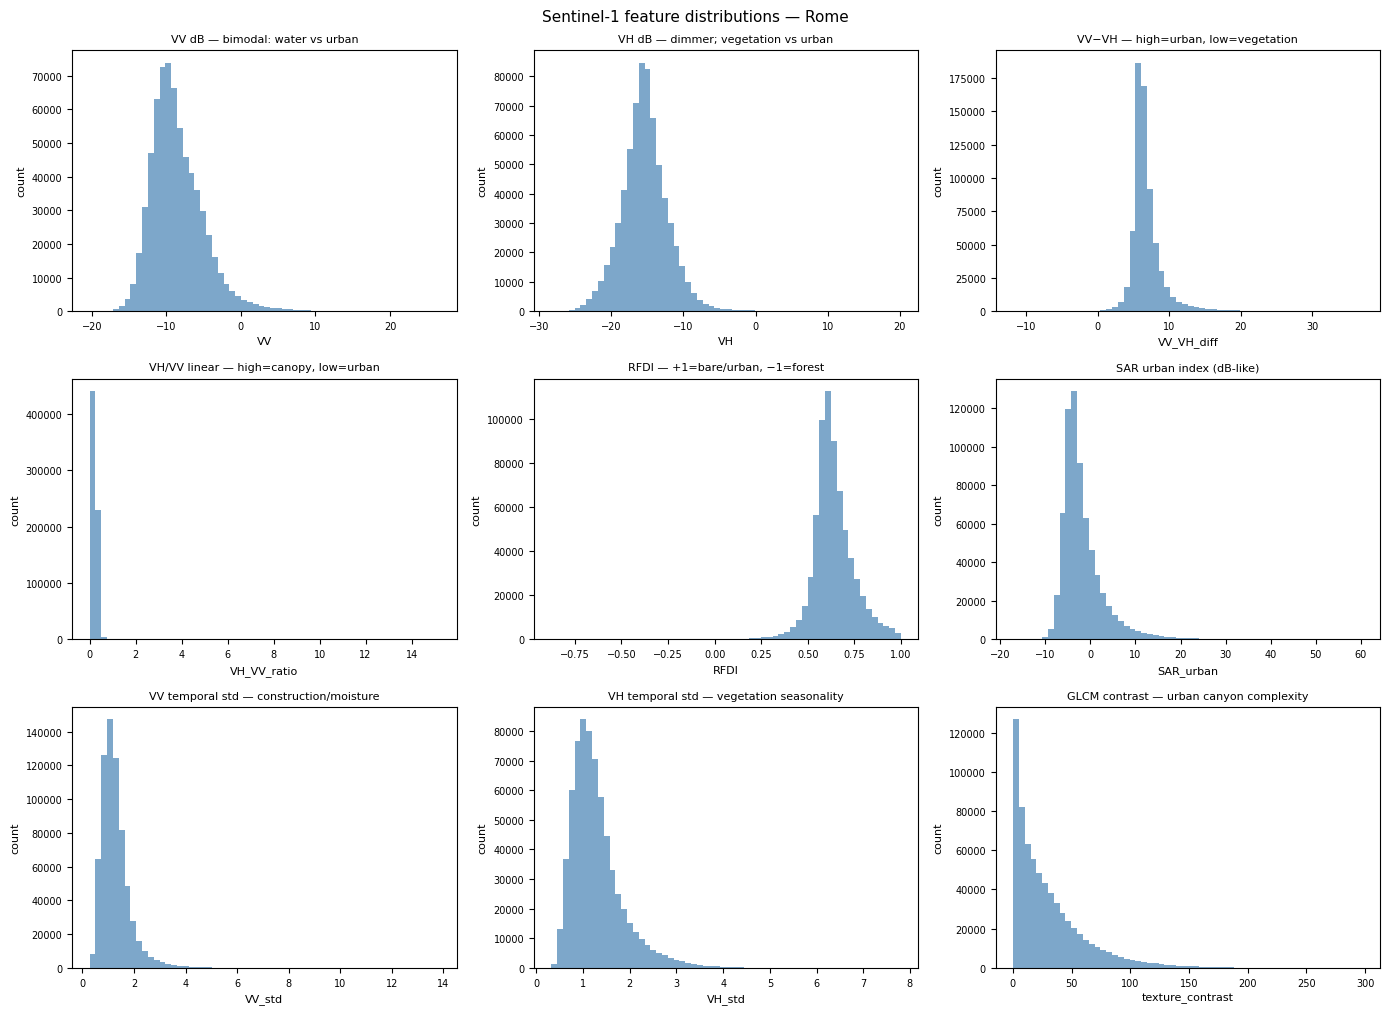

Saved: s1_feature_distributions.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

feature_cols = ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio',
                'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast']

descriptions = [
    'VV dB — bimodal: water vs urban',
    'VH dB — dimmer; vegetation vs urban',
    'VV−VH — high=urban, low=vegetation',
    'VH/VV linear — high=canopy, low=urban',
    'RFDI — +1=bare/urban, −1=forest',
    'SAR urban index (dB-like)',
    'VV temporal std — construction/moisture',
    'VH temporal std — vegetation seasonality',
    'GLCM contrast — urban canyon complexity'
]

for ax, col, desc in zip(axes, feature_cols, descriptions):
    ax.hist(df[col].dropna(), bins=60, color='steelblue', alpha=0.7, edgecolor='none')
    ax.set_title(desc, fontsize=8)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.suptitle('Sentinel-1 feature distributions — Rome', y=1.01, fontsize=11)
# plt.savefig('s1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s1_feature_distributions.png')

In [ ]:
# treat outliers

# Only clip extreme outliers, not the physically valid range
p99 = df['VH_VV_ratio'].quantile(0.99)
print(f'99th percentile: {p99:.3f}')
df['VH_VV_ratio'] = df['VH_VV_ratio'].clip(upper=p99)


p99 = df['SAR_urban'].quantile(0.99)
df['SAR_urban'] = df['SAR_urban'].clip(upper=p99)


# log transform the texture contrast to reduce skewness
df['texture_contrast'] = np.log1p(df['texture_contrast'])

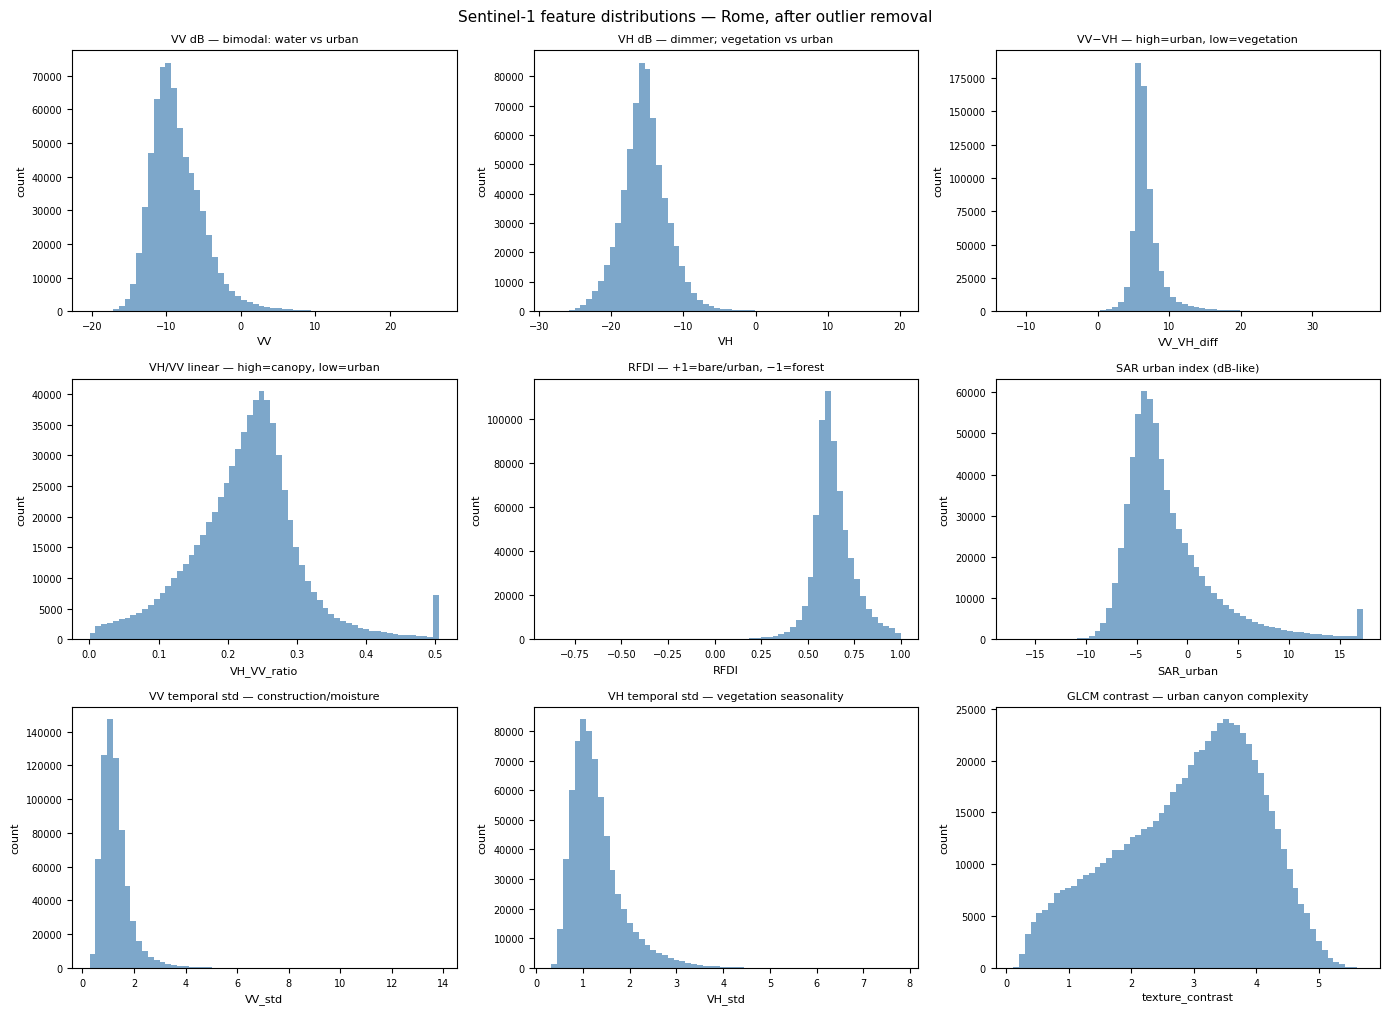

Saved: s1_feature_distributions.png


In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

feature_cols = ['VV', 'VH', 'VV_VH_diff', 'VH_VV_ratio',
                'RFDI', 'SAR_urban', 'VV_std', 'VH_std', 'texture_contrast']

descriptions = [
    'VV dB — bimodal: water vs urban',
    'VH dB — dimmer; vegetation vs urban',
    'VV−VH — high=urban, low=vegetation',
    'VH/VV linear — high=canopy, low=urban',
    'RFDI — +1=bare/urban, −1=forest',
    'SAR urban index (dB-like)',
    'VV temporal std — construction/moisture',
    'VH temporal std — vegetation seasonality',
    'GLCM contrast — urban canyon complexity'
]

for ax, col, desc in zip(axes, feature_cols, descriptions):
    ax.hist(df[col].dropna(), bins=60, color='steelblue', alpha=0.7, edgecolor='none')
    ax.set_title(desc, fontsize=8)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.suptitle('Sentinel-1 feature distributions — Rome, after outlier removal', y=1.01, fontsize=11)
# plt.savefig('s1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: s1_feature_distributions.png')

## 10. Export

Two export options:
- **Option A** — local CSV (works for small samples)
- **Option B** — GeoTIFF to Google Drive (for the full raster, then join in GEE or locally)

In [31]:
# ── Option A: local CSV ────────────────────────────────────────────────────────
csv_path = 'rome_s1_features.csv'
df.to_csv(csv_path, index=False)
print(f'Saved {len(df)} rows to {csv_path}')
df.head(3)

Saved 677735 rows to rome_s1_features.csv


,VV,VH,VV_VH_diff,VH_VV_ratio,RFDI,SAR_urban,VV_std,VH_std,texture_contrast,x_utm,y_utm,lon,lat
0,-10.388566,-16.534420,6.145855,0.242893,0.609149,-4.242711,0.527717,0.708021,0.590561,280515.0,4653165.0,12.349883,41.999919
1,-10.671421,-16.463101,5.791680,0.263531,0.582866,-4.879741,0.641854,0.906207,0.673612,280545.0,4653165.0,12.350245,41.999928
2,-10.706261,-16.585046,5.878785,0.258298,0.589448,-4.827475,0.468242,0.716338,0.682525,280575.0,4653165.0,12.350606,41.999936


In [ ]:
# ── Option B: GeoTIFF to Google Drive (uncomment to run) ──────────────────────
# This exports the full 30 m raster — useful for spatial joins in QGIS or rasterio.

# task = ee.batch.Export.image.toDrive(
#     image=s1_features,
#     description='rome_s1_features_30m',
#     folder='UHI_Rome',
#     scale=SCALE,
#     crs='EPSG:32633',
#     region=aoi,
#     maxPixels=1e9,
#     fileFormat='GeoTIFF'
# )
# task.start()
# print('Export task started. Check https://code.earthengine.google.com → Tasks.')

## 11. What comes next — joining with Landsat LST

The S1 feature CSV has `(lon, lat)` coordinates at 30 m spacing.
Your Landsat pipeline will produce a similar CSV with LST + optical features at the same grid.

Join them like this:

```python
import pandas as pd

s1_df  = pd.read_csv('rome_s1_features.csv')
lst_df = pd.read_csv('rome_landsat_lst_features.csv')  # your Landsat output

# Round coordinates to avoid float precision mismatches
for df in [s1_df, lst_df]:
    df['lon'] = df['lon'].round(5)
    df['lat'] = df['lat'].round(5)

merged = pd.merge(s1_df, lst_df, on=['lon', 'lat'], how='inner')
print(f'Merged rows: {len(merged)}')
print(merged.columns.tolist())
```

The `merged` DataFrame is your full modelling dataset:
- **Target**: `LST`
- **Baseline features**: NDVI, NDWI, PIS, PGS, albedo, NLI, BH, BD, SVF
- **S1 features**: VV, VH, VV_VH_diff, VH_VV_ratio, RFDI, SAR_urban, VV_std, VH_std, texture_contrast

Then run XGBoost twice — baseline only, then baseline + S1 — and compare RMSE and SHAP rankings.